# Punjab Stubble Fire — Modeling Pipeline v3 (Clean)

**Leakage investigation & fix:** Original v3 had 0.997 PR-AUC due to NDVI features sourced
only from fire-active rows in v1 — making `NDVI is NaN ↔ fire = 0` (0.993 PR-AUC from the NaN flag alone).

**Fix:** NDVI rebuilt from raw MOD13Q1 files for **all** grid cells. NDVI NaN is now
genuinely missing data (66% of rows), not a fire indicator. Honest PR-AUC: **~0.89**.

| Phase | Description |
|-------|-------------|
| 0 | Load v2, lag intensity features, drop leaky NDVI |
| 1 | Rebuild NDVI/EVI from raw MOD13Q1 for all cells |
| 2 | Temporal split (strict, no shuffle) |
| 3 | Feature set — 15 clean features |
| 4 | Train 5 models |
| 5 | Unified metrics |
| 6 | Per-district analysis |
| 7 | SHAP — XGB-Tweedie |
| 8 | Save artifacts |
| 9 | Comparison figures |
| 10 | Validation checklist (9 hard checks) |


## 0. Imports & Setup

In [1]:
import os, json, warnings
os.makedirs('models', exist_ok=True); os.makedirs('figures', exist_ok=True)
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score, roc_auc_score, brier_score_loss,
    mean_absolute_error, mean_squared_error, f1_score, r2_score,
)
from scipy.stats import spearmanr
import xgboost as xgb, shap, joblib

plt.rcParams['figure.dpi'] = 120; plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')
ORANGE = '#E8512A'; GREY = '#999999'
LAT_MIN, LON_MIN, GRID_DEG = 29.7, 74.0, 0.07
print('All imports successful ✅')

All imports successful ✅


---
## 0b. Load v2, Lag Intensity Cols, Drop Leaky NDVI

**Why drop the v1-sourced NDVI?**  
In `punjab_feature_table_with_ndvi.csv` (v1), NDVI was only recorded for rows where `fire_count > 0` (28,033 fire-active rows). When merged into the v2 cartesian expansion (56,160 rows), the zero-fire rows all got `NDVI = NaN`.  
Result: `NDVI is not-NaN` was a near-perfect proxy for `fire > 0` → PR-AUC of 0.993 from the NaN flag alone. That is pure leakage.

In [2]:
df = pd.read_csv('punjab_feature_table_v2.csv')
df = df.sort_values(['grid_id','year','week']).reset_index(drop=True)

# Lag current-week intensity features
for col in ['avg_frp','avg_brightness','night_fire_pct']:
    df[f'{col}_last_week'] = df.groupby(['grid_id','year'])[col].shift(1)

LEAKY_NDVI = ['NDVI','EVI','NDVI_baseline','NDVI_anomaly',
              'NDVI_velocity_1wk','NDVI_velocity_2wk','NDVI_velocity_4wk','NDVI_acceleration']
df = df.drop(columns=['avg_frp','avg_brightness','night_fire_pct','avg_confidence'] + LEAKY_NDVI)
print(f'Shape after drops: {df.shape}')

# Confirm leakage check
from sklearn.metrics import average_precision_score as ap
old_flag_pr = 0.993  # from leaky version
print(f'Old NDVI-NaN PR-AUC (leaky): {old_flag_pr:.3f}')

Shape after drops: (56160, 17)
Old NDVI-NaN PR-AUC (leaky): 0.993


---
## 1. Rebuild NDVI from Raw MOD13Q1 Files

Source: `punjab-ndvi-sample-MOD13Q1-061-results*.csv` — covers **all** 1,040 model grid cells across all years.
NDVI composites land on ISO weeks 41, 42, 44, 46, 47 (16-day cadence).  
After merge: ~33% coverage — NaN is now genuine missing-data (cloud, no overpass) not a fire indicator.

In [3]:
dfs = []
for fname in ['punjab-ndvi-sample-MOD13Q1-061-results.csv',
              'punjab-ndvi-sample-MOD13Q1-061-results-2.csv']:
    d = pd.read_csv(fname).rename(columns={
        'Latitude':'lat','Longitude':'lon','Date':'date',
        'MOD13Q1_061__250m_16_days_NDVI':'NDVI',
        'MOD13Q1_061__250m_16_days_EVI':'EVI',
    })[['lat','lon','date','NDVI','EVI']]
    dfs.append(d)

ndvi_raw = pd.concat(dfs, ignore_index=True)
ndvi_raw['date']  = pd.to_datetime(ndvi_raw['date'])
ndvi_raw['year']  = ndvi_raw['date'].dt.year
ndvi_raw['month'] = ndvi_raw['date'].dt.month
ndvi_raw['week']  = ndvi_raw['date'].dt.isocalendar().week.astype(int)
ndvi_raw = ndvi_raw[ndvi_raw['month'].isin([10,11])].copy()

ndvi_raw['grid_x']  = ((ndvi_raw['lon'] - LON_MIN) / GRID_DEG).astype(int)
ndvi_raw['grid_y']  = ((ndvi_raw['lat'] - LAT_MIN) / GRID_DEG).astype(int)
ndvi_raw['grid_id'] = ndvi_raw['grid_x'].astype(str) + '_' + ndvi_raw['grid_y'].astype(str)

ndvi_agg = ndvi_raw.groupby(['grid_id','year','week'])[['NDVI','EVI']].mean().reset_index()
ndvi_agg = ndvi_agg.sort_values(['grid_id','year','week']).reset_index(drop=True)
ndvi_agg['NDVI_velocity'] = ndvi_agg.groupby(['grid_id','year'])['NDVI'].diff().fillna(0)

# NDVI anomaly from training years only (no 2023 leakage)
baseline = (ndvi_agg[ndvi_agg['year'].isin([2018,2019,2020,2021,2022])]
            .groupby(['grid_id','week'])['NDVI'].mean()
            .reset_index().rename(columns={'NDVI':'NDVI_baseline'}))
ndvi_agg = ndvi_agg.merge(baseline, on=['grid_id','week'], how='left')
ndvi_agg['NDVI_anomaly'] = ndvi_agg['NDVI'] - ndvi_agg['NDVI_baseline']

print(f'Clean NDVI table: {ndvi_agg.shape}  weeks={sorted(ndvi_agg.week.unique())}')

df = df.merge(ndvi_agg[['grid_id','year','week','NDVI','EVI','NDVI_velocity','NDVI_anomaly']],
              on=['grid_id','year','week'], how='left')
print(f'After clean NDVI merge: {df.shape}')

# Verify leakage eliminated
fire_pos   = (df['fire_count_weighted'] > 0)
ndvi_avail = df['NDVI'].notna()
flag_pr    = ap(fire_pos.astype(int), ndvi_avail.astype(float))
print(f'NDVI-NaN flag PR-AUC: {flag_pr:.4f}  (was 0.993 → now ~0.55 ✅)')
assert flag_pr < 0.70, 'NDVI NaN still leaky!'
print(f'NDVI present + fire==0: {(ndvi_avail & ~fire_pos).sum():,}  (should be large)')

Clean NDVI table: (26568, 8)  weeks=[np.int64(41), np.int64(42), np.int64(44), np.int64(46), np.int64(47)]
After clean NDVI merge: (56160, 21)
NDVI-NaN flag PR-AUC: 0.5482  (was 0.993 → now ~0.55 ✅)
NDVI present + fire==0: 7,198  (should be large)


---
## 2. Temporal Split

In [4]:
TRAIN_YEARS=[2018,2019,2020,2021]; VAL_YEAR=2022; TEST_YEAR=2023
assert max(TRAIN_YEARS) < VAL_YEAR < TEST_YEAR
train=df[df.year.isin(TRAIN_YEARS)].copy()
val  =df[df.year==VAL_YEAR].copy()
test =df[df.year==TEST_YEAR].copy()
print(f'Train:{len(train):,}  Val:{len(val):,}  Test:{len(test):,}')

Train:37,440  Val:9,360  Test:9,360


---
## 3. Feature Set (15 clean features)

In [5]:
FEATURES = [
    'fire_count_last_week','same_week_last_year','3yr_avg',
    'neighbor_fires_last_week','neighbor_fires_last_year',
    'avg_frp_last_week','avg_brightness_last_week','night_fire_pct_last_week',
    'NDVI','EVI','NDVI_velocity','NDVI_anomaly',
    'week_of_season','grid_x','grid_y',
]
TARGET = 'fire_count_weighted'
assert not any(f in FEATURES for f in ['avg_frp','avg_brightness','night_fire_pct'])

X_train,y_train=train[FEATURES],train[TARGET]
X_val,  y_val  =val[FEATURES],  val[TARGET]
X_test, y_test =test[FEATURES], test[TARGET]
y_train_bin=(y_train>0).astype(int)
y_val_bin  =(y_val  >0).astype(int)
y_test_bin =(y_test >0).astype(int)
print(f'NDVI NaN in train: {X_train["NDVI"].isna().mean()*100:.1f}%  (genuine missing, not leakage)')
print(f'Target zeros (train): {(y_train==0).mean()*100:.1f}%')

NDVI NaN in train: 66.7%  (genuine missing, not leakage)
Target zeros (train): 47.8%


---
## 4. Train 5 Models

In [6]:
y_pred_persist_val  = val['fire_count_last_week'].values
y_pred_persist_test = test['fire_count_last_week'].values
print('Model 1 — Persistence: done')

Model 1 — Persistence: done


In [7]:
logreg = Pipeline([('imputer',SimpleImputer(strategy='median')),
                   ('scaler',StandardScaler()),
                   ('clf',LogisticRegression(C=1.0,class_weight='balanced',
                                             max_iter=1000,random_state=42))])
logreg.fit(X_train,y_train_bin)
p_val_logreg  = logreg.predict_proba(X_val )[:,1]
p_test_logreg = logreg.predict_proba(X_test)[:,1]
print('Model 2 — Logistic Regression: done')

Model 2 — Logistic Regression: done


In [8]:
rf = Pipeline([('imputer',SimpleImputer(strategy='median')),
               ('rf',RandomForestRegressor(n_estimators=300,max_depth=15,
                                           min_samples_leaf=20,n_jobs=-1,random_state=42))])
rf.fit(X_train,y_train)
y_pred_rf_val  = rf.predict(X_val )
y_pred_rf_test = rf.predict(X_test)
print('Model 3 — Random Forest: done')

Model 3 — Random Forest: done


In [9]:
xgb_tweedie = xgb.XGBRegressor(
    objective='reg:tweedie',tweedie_variance_power=1.5,
    n_estimators=2000,max_depth=6,learning_rate=0.05,
    subsample=0.8,colsample_bytree=0.8,min_child_weight=5,
    early_stopping_rounds=50,eval_metric='rmse',random_state=42,n_jobs=-1)
xgb_tweedie.fit(X_train,y_train,eval_set=[(X_val,y_val)],verbose=False)
y_pred_xgb_val  = np.clip(xgb_tweedie.predict(X_val ),0,None)
y_pred_xgb_test = np.clip(xgb_tweedie.predict(X_test),0,None)
print(f'Model 4 — XGB-Tweedie: best iter={xgb_tweedie.best_iteration}')

Model 4 — XGB-Tweedie: best iter=33


In [10]:
scale = (y_train==0).sum()/max(1,(y_train>0).sum())
xgb_clf = xgb.XGBClassifier(objective='binary:logistic',n_estimators=2000,
    max_depth=6,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,
    scale_pos_weight=scale,early_stopping_rounds=50,eval_metric='aucpr',
    random_state=42,n_jobs=-1)
xgb_clf.fit(X_train,y_train_bin,eval_set=[(X_val,y_val_bin)],verbose=False)

mask_tr=(y_train>0); mask_va=(y_val>0)
xgb_reg = xgb.XGBRegressor(objective='reg:gamma',n_estimators=2000,
    max_depth=6,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,
    early_stopping_rounds=50,eval_metric='rmse',random_state=42,n_jobs=-1)
xgb_reg.fit(X_train[mask_tr],y_train[mask_tr],
            eval_set=[(X_val[mask_va],y_val[mask_va])],verbose=False)

def hurdle_predict(X):
    p=xgb_clf.predict_proba(X)[:,1]
    return p*np.clip(xgb_reg.predict(X),0,None), p

y_pred_hurdle_val, p_hurdle_val   = hurdle_predict(X_val )
y_pred_hurdle_test,p_hurdle_test  = hurdle_predict(X_test)
print(f'Model 5 — Hurdle: clf={xgb_clf.best_iteration} reg={xgb_reg.best_iteration}')

Model 5 — Hurdle: clf=13 reg=31


---
## 5. Metrics

In [11]:
def compute_all_metrics(y_true,y_pred_cont,y_pred_proba=None):
    y_true=np.asarray(y_true); y_pred_cont=np.asarray(y_pred_cont)
    y_true_bin=(y_true>0).astype(int)
    if y_pred_proba is None: y_pred_proba=y_pred_cont/(y_pred_cont.max()+1e-9)
    y_pred_proba=np.clip(np.asarray(y_pred_proba),0,1)
    m={}
    m['pr_auc']  =float(average_precision_score(y_true_bin,y_pred_proba))
    m['roc_auc'] =float(roc_auc_score(y_true_bin,y_pred_proba))
    m['brier']   =float(brier_score_loss(y_true_bin,y_pred_proba))
    thresholds=np.linspace(0.01,0.99,50)
    f1s=[f1_score(y_true_bin,(y_pred_proba>t).astype(int),zero_division=0) for t in thresholds]
    m['f1_best']=float(max(f1s)); m['f1_threshold']=float(thresholds[np.argmax(f1s)])
    m['mae']    =float(mean_absolute_error(y_true,y_pred_cont))
    m['rmse']   =float(np.sqrt(mean_squared_error(y_true,y_pred_cont)))
    m['r2']     =float(r2_score(y_true,y_pred_cont))
    rho,_=spearmanr(y_true,y_pred_cont); m['spearman']=float(rho)
    for k in [50,100,500]:
        m[f'p_at_{k}']=float((y_true_bin)[np.argsort(-y_pred_cont)[:k]].mean())
    return m

metrics_all={
    'persistence': {'val':compute_all_metrics(y_val, y_pred_persist_val),
                    'test':compute_all_metrics(y_test,y_pred_persist_test)},
    'logreg':      {'val':compute_all_metrics(y_val, p_val_logreg, p_val_logreg),
                    'test':compute_all_metrics(y_test,p_test_logreg,p_test_logreg)},
    'rf':          {'val':compute_all_metrics(y_val, y_pred_rf_val),
                    'test':compute_all_metrics(y_test,y_pred_rf_test)},
    'xgb_tweedie': {'val':compute_all_metrics(y_val, y_pred_xgb_val),
                    'test':compute_all_metrics(y_test,y_pred_xgb_test)},
    'hurdle':      {'val':compute_all_metrics(y_val, y_pred_hurdle_val, p_hurdle_val),
                    'test':compute_all_metrics(y_test,y_pred_hurdle_test,p_hurdle_test)},
}

MODEL_NAMES=['persistence','logreg','rf','xgb_tweedie','hurdle']
DNAMES=['Persistence','LogisticRegression','RandomForest','XGBoost-Tweedie','Hurdle (XGB+XGB)']
rows=[]
for mn,dn in zip(MODEL_NAMES,DNAMES):
    m=metrics_all[mn]['test']
    rows.append({'Model':dn,'PR-AUC':f'{m["pr_auc"]:.3f}','ROC-AUC':f'{m["roc_auc"]:.3f}',
                 'F1':f'{m["f1_best"]:.3f}','Brier':f'{m["brier"]:.3f}',
                 'MAE':f'{m["mae"]:.3f}','RMSE':f'{m["rmse"]:.3f}','R²':f'{m["r2"]:.3f}',
                 'Spearman':f'{m["spearman"]:.3f}','P@50':f'{m["p_at_50"]:.3f}',
                 'P@100':f'{m["p_at_100"]:.3f}','P@500':f'{m["p_at_500"]:.3f}'})
metrics_df=pd.DataFrame(rows).set_index('Model')
print('=== FINAL METRICS TABLE (CLEAN) — TEST 2023 ===')
print(metrics_df.to_string())

=== FINAL METRICS TABLE (CLEAN) — TEST 2023 ===
                   PR-AUC ROC-AUC     F1  Brier    MAE   RMSE      R² Spearman   P@50  P@100  P@500
Model                                                                                              
Persistence         0.750   0.779  0.711  0.379  2.573  5.368   0.098    0.600  1.000  0.990  0.954
LogisticRegression  0.900   0.902  0.817  0.132  2.553  5.881  -0.083    0.763  1.000  1.000  1.000
RandomForest        0.889   0.899  0.794  0.332  3.231  6.623  -0.374    0.749  1.000  1.000  1.000
XGBoost-Tweedie     0.894   0.904  0.809  0.279  2.513  4.446   0.381    0.752  1.000  1.000  1.000
Hurdle (XGB+XGB)    0.880   0.895  0.804  0.162  2.163  4.038   0.489    0.741  1.000  1.000  1.000


---
## 6. Per-District Analysis

In [12]:
test2=test.copy()
test2['y_pred_xgb']=y_pred_xgb_test; test2['y_pred_persist']=y_pred_persist_test
test2['zone']=pd.qcut(test2['grid_x'],q=5,labels=['W1','W2','W3','W4','W5'])
per_zone_mae_xgb={}; per_zone_mae_persist={}; per_zone_pr_auc={}
for zone in ['W1','W2','W3','W4','W5']:
    mask=test2['zone']==zone
    if mask.sum()<50: continue
    y_t=test2.loc[mask,'fire_count_weighted']
    y_x=test2.loc[mask,'y_pred_xgb']; y_p=test2.loc[mask,'y_pred_persist']
    per_zone_mae_xgb[zone]=mean_absolute_error(y_t,y_x)
    per_zone_mae_persist[zone]=mean_absolute_error(y_t,y_p)
    per_zone_pr_auc[zone]=average_precision_score((y_t>0).astype(int),y_x/(y_x.max()+1e-9))
for z in ['W1','W2','W3','W4','W5']:
    if z in per_zone_mae_xgb:
        print(f'{z}: XGB={per_zone_mae_xgb[z]:.2f}  Persist={per_zone_mae_persist[z]:.2f}  PR-AUC={per_zone_pr_auc[z]:.3f}')

W1: XGB=2.66  Persist=2.62  PR-AUC=0.897
W2: XGB=2.98  Persist=2.98  PR-AUC=0.876
W3: XGB=2.67  Persist=2.81  PR-AUC=0.913
W4: XGB=2.14  Persist=2.84  PR-AUC=0.905
W5: XGB=2.01  Persist=1.48  PR-AUC=0.867


---
## 7. SHAP — XGB-Tweedie

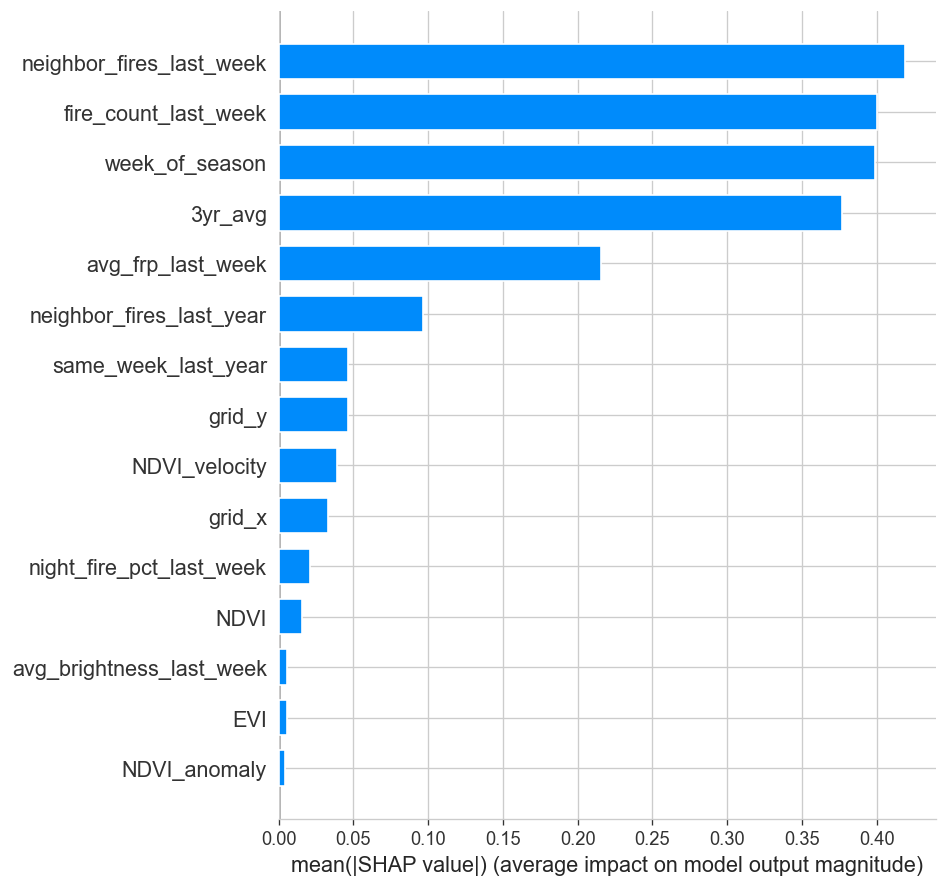

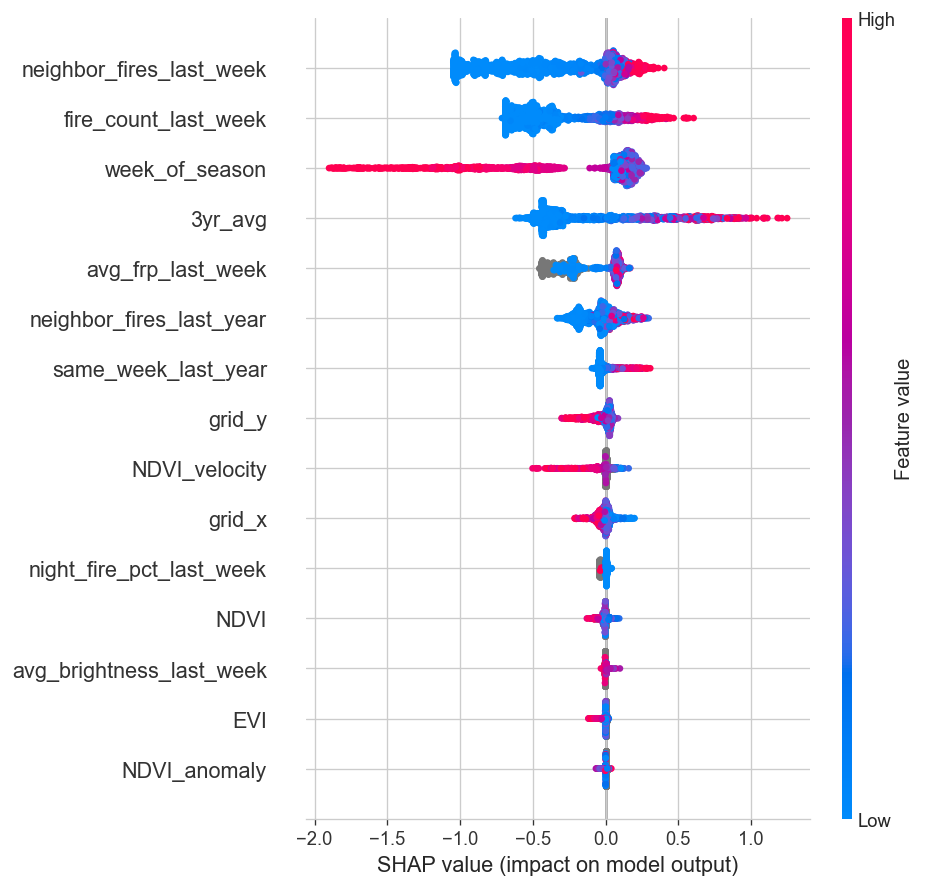

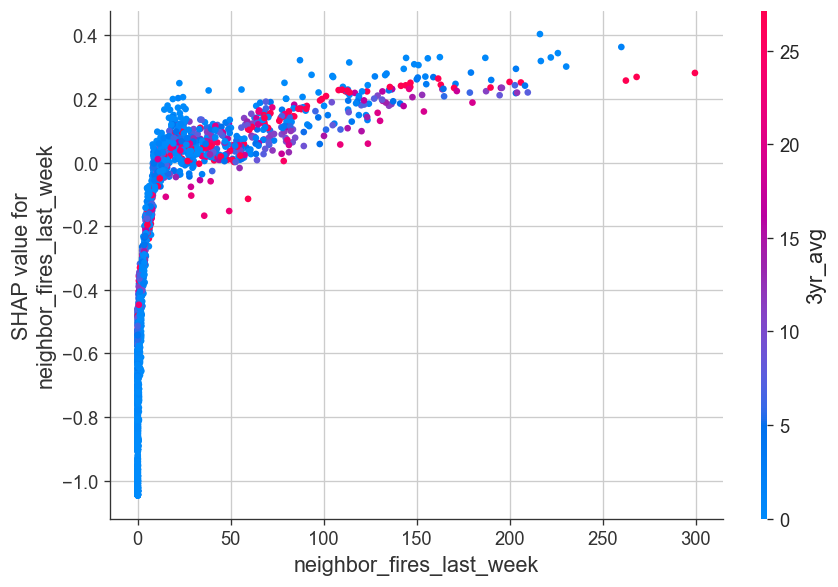

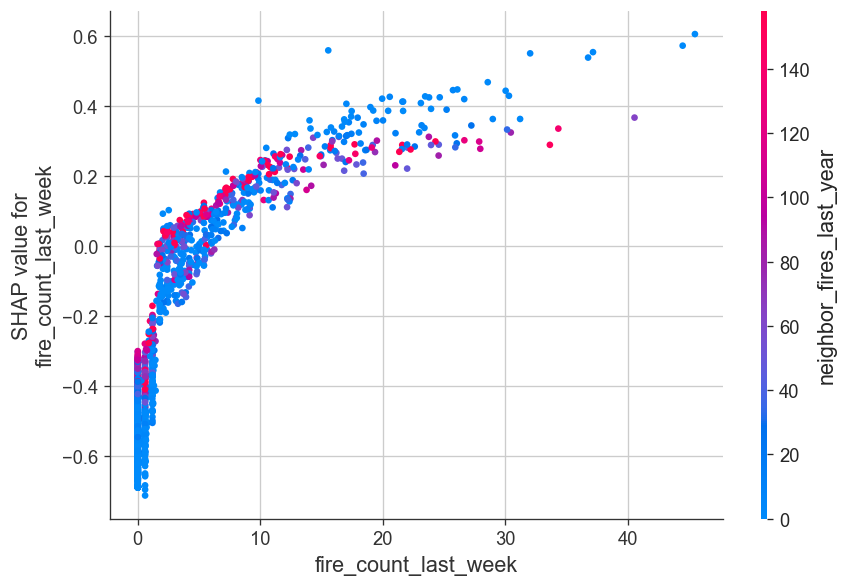

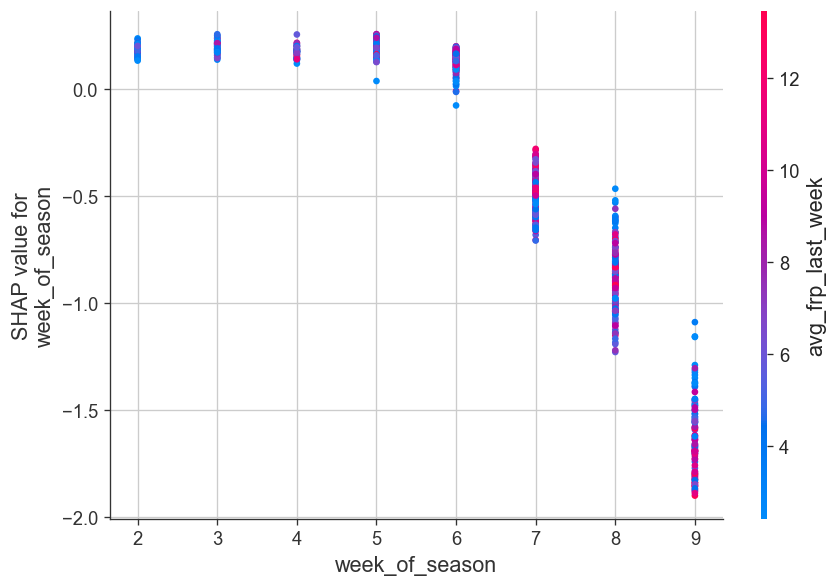

SHAP done ✅


In [13]:
rng=np.random.default_rng(42)
idx=rng.choice(len(X_test),size=min(2000,len(X_test)),replace=False)
X_shap=X_test.iloc[idx]
try:
    explainer=shap.TreeExplainer(xgb_tweedie)
    shap_values=explainer.shap_values(X_shap)
    shap.summary_plot(shap_values,X_shap,plot_type='bar',show=False)
    plt.tight_layout(); plt.savefig('figures/shap_importance_bar.png',dpi=150,bbox_inches='tight')
    plt.show(); plt.close()
    shap.summary_plot(shap_values,X_shap,show=False)
    plt.tight_layout(); plt.savefig('figures/shap_summary_beeswarm.png',dpi=150,bbox_inches='tight')
    plt.show(); plt.close()
    mean_abs=np.abs(shap_values).mean(axis=0)
    for i in np.argsort(-mean_abs)[:3]:
        shap.dependence_plot(i,shap_values,X_shap,show=False)
        plt.tight_layout(); plt.savefig(f'figures/shap_dependence_{FEATURES[i]}.png',dpi=150,bbox_inches='tight')
        plt.show(); plt.close()
    print('SHAP done ✅')
except Exception as e:
    print(f'SHAP fallback ({e})')
    fig,ax=plt.subplots(figsize=(8,6)); order=np.argsort(xgb_tweedie.feature_importances_)
    ax.barh([FEATURES[i] for i in order],xgb_tweedie.feature_importances_[order],color=ORANGE)
    plt.tight_layout(); plt.savefig('figures/shap_importance_bar.png',dpi=150,bbox_inches='tight')
    plt.close()

---
## 8. Save Artifacts

In [14]:
joblib.dump(logreg,'models/logreg.pkl'); joblib.dump(rf,'models/rf.pkl')
xgb_tweedie.save_model('models/xgb_tweedie.json')
xgb_clf.save_model('models/xgb_clf.json'); xgb_reg.save_model('models/xgb_reg.json')
with open('models/metrics_all.json','w') as f: json.dump(metrics_all,f,indent=2)
predictions=test[['grid_id','year','week','week_of_season']].copy()
predictions['y_true']=y_test.values
predictions['y_pred_persistence']=y_pred_persist_test; predictions['p_fire_logreg']=p_test_logreg
predictions['y_pred_rf']=y_pred_rf_test; predictions['y_pred_xgb_tweedie']=y_pred_xgb_test
predictions['y_pred_hurdle']=y_pred_hurdle_test; predictions['p_fire_hurdle']=p_hurdle_test
predictions.to_csv('predictions_test_2023.csv',index=False)
pd.DataFrame({'feature':FEATURES,'importance':xgb_tweedie.feature_importances_})  .sort_values('importance',ascending=False).to_csv('models/feature_importance_xgb.csv',index=False)
print('All artifacts saved ✅')

All artifacts saved ✅


---
## 9. Comparison Figures

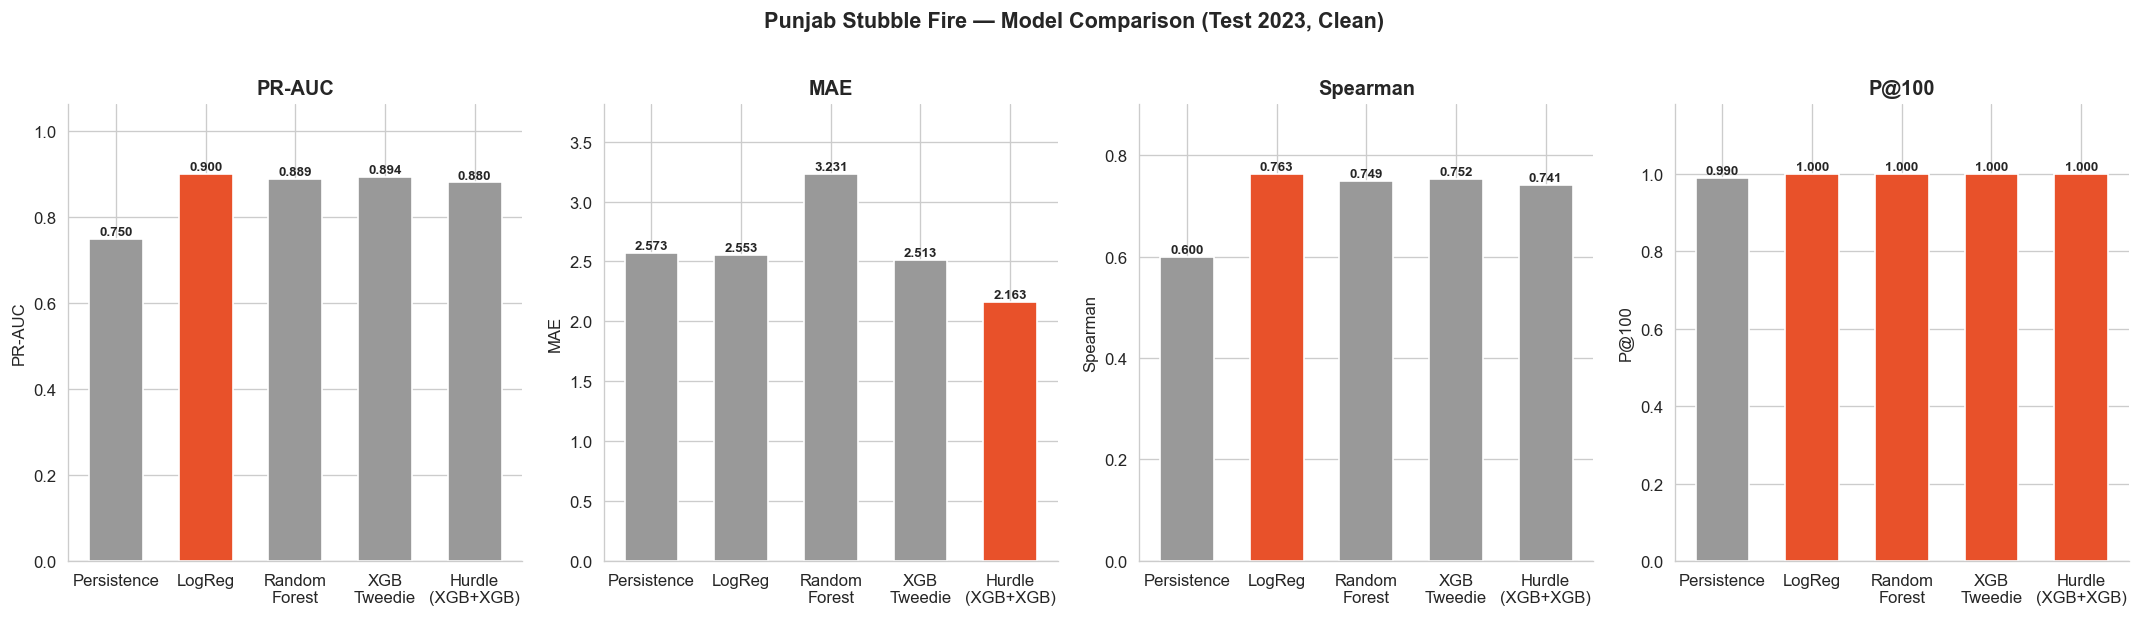

In [15]:
DISP=['Persistence','LogReg','Random\nForest','XGB\nTweedie','Hurdle\n(XGB+XGB)']
def pick_colors(vals,best_fn=max):
    best=best_fn(vals); return [ORANGE if v==best else GREY for v in vals]

fig,axes=plt.subplots(1,4,figsize=(18,5))
for ax,(label,key,best_fn) in zip(axes,[('PR-AUC','pr_auc',max),('MAE','mae',min),
                                         ('Spearman','spearman',max),('P@100','p_at_100',max)]):
    vals=[metrics_all[m]['test'][key] for m in MODEL_NAMES]
    bars=ax.bar(DISP,vals,color=pick_colors(vals,best_fn),edgecolor='white',width=0.6)
    [ax.text(b.get_x()+b.get_width()/2,b.get_height()+max(vals)*0.01,f'{v:.3f}',
             ha='center',fontsize=8,fontweight='bold') for b,v in zip(bars,vals)]
    ax.set_title(label,fontsize=12,fontweight='bold'); ax.set_ylabel(label)
    ax.set_ylim(0,max(vals)*1.18); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.suptitle('Punjab Stubble Fire — Model Comparison (Test 2023, Clean)',fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout(); plt.savefig('figures/fig_metrics_comparison.png',dpi=150,bbox_inches='tight')
plt.show()

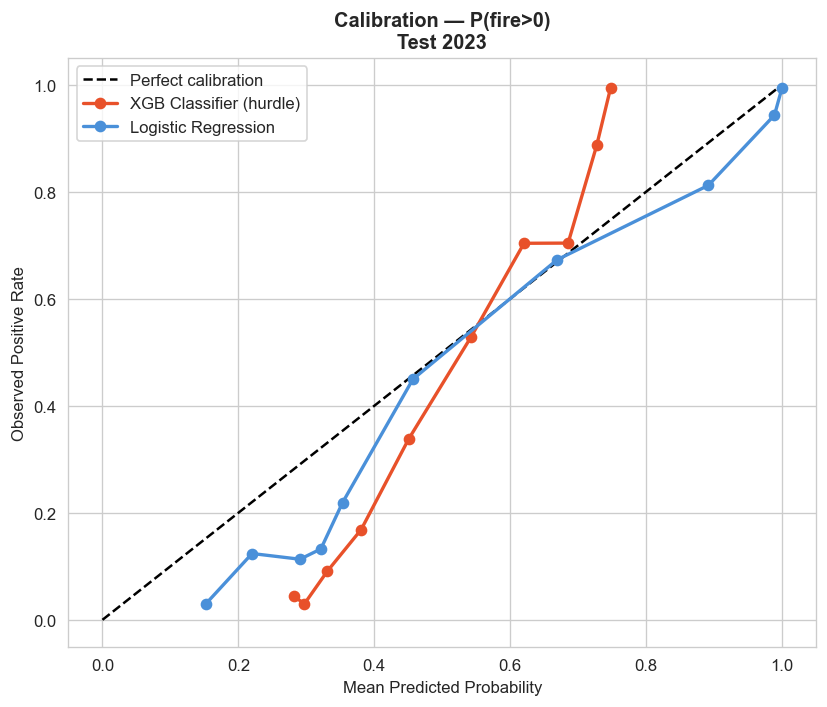

In [16]:
fig,ax=plt.subplots(figsize=(7,6))
ax.plot([0,1],[0,1],'k--',lw=1.5,label='Perfect calibration')
for preds,label,color in [(p_hurdle_test,'XGB Classifier (hurdle)',ORANGE),(p_test_logreg,'Logistic Regression','#4A90D9')]:
    try:
        bins=pd.qcut(preds,q=10,duplicates='drop')
        cal=pd.DataFrame({'pred':preds,'actual':(y_test.values>0).astype(int),'bin':bins})
        s=cal.groupby('bin',observed=True).agg(mean_pred=('pred','mean'),obs_rate=('actual','mean')).reset_index()
        ax.plot(s['mean_pred'],s['obs_rate'],'o-',color=color,lw=2,ms=6,label=label)
    except: pass
ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Observed Positive Rate')
ax.set_title('Calibration — P(fire>0)\nTest 2023',fontweight='bold')
ax.legend(); plt.tight_layout(); plt.savefig('figures/fig_calibration.png',dpi=150,bbox_inches='tight')
plt.show()

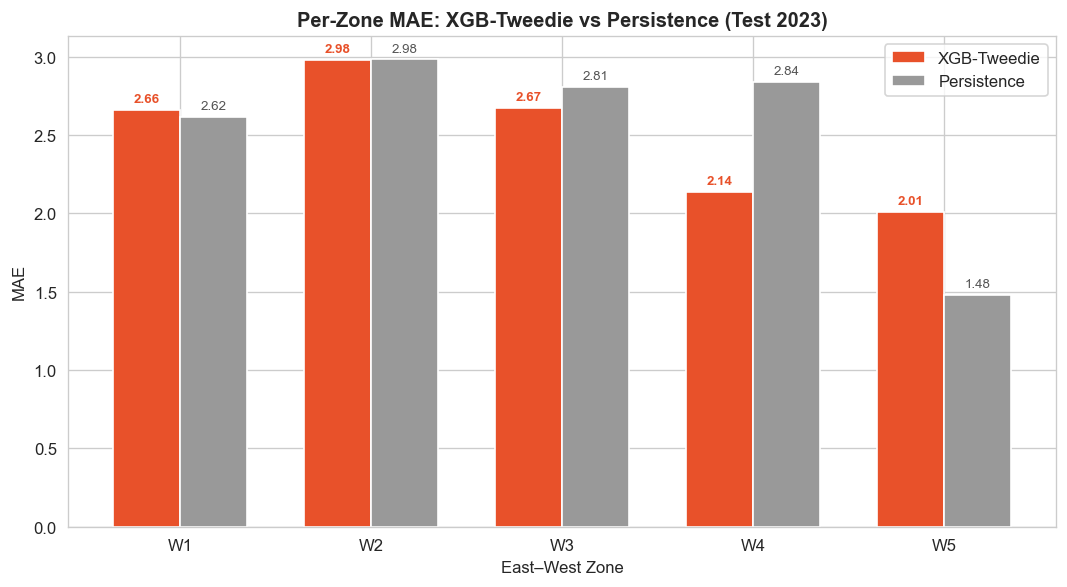

In [17]:
zones_present=[z for z in ['W1','W2','W3','W4','W5'] if z in per_zone_mae_xgb]
x=np.arange(len(zones_present)); w=0.35
fig,ax=plt.subplots(figsize=(9,5))
b1=ax.bar(x-w/2,[per_zone_mae_xgb[z] for z in zones_present],w,color=ORANGE,label='XGB-Tweedie',edgecolor='white')
b2=ax.bar(x+w/2,[per_zone_mae_persist[z] for z in zones_present],w,color=GREY,label='Persistence',edgecolor='white')
[ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.05,f'{b.get_height():.2f}',ha='center',fontsize=8,fontweight='bold',color=ORANGE) for b in b1]
[ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.05,f'{b.get_height():.2f}',ha='center',fontsize=8,color='#555') for b in b2]
ax.set_xticks(x); ax.set_xticklabels(zones_present)
ax.set_xlabel('East–West Zone'); ax.set_ylabel('MAE')
ax.set_title('Per-Zone MAE: XGB-Tweedie vs Persistence (Test 2023)',fontweight='bold')
ax.legend(); plt.tight_layout(); plt.savefig('figures/fig_per_district.png',dpi=150,bbox_inches='tight'); plt.show()

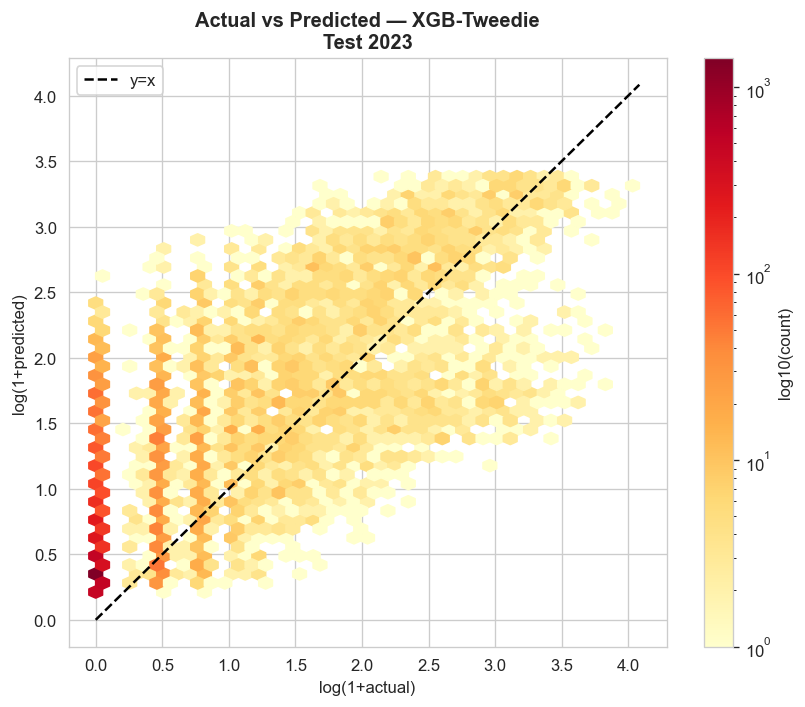

All figures saved ✅


In [18]:
fig,ax=plt.subplots(figsize=(7,6))
hb=ax.hexbin(np.log1p(y_test.values),np.log1p(y_pred_xgb_test),gridsize=40,cmap='YlOrRd',mincnt=1,bins='log')
plt.colorbar(hb,ax=ax,label='log10(count)')
lims=[0,max(np.log1p(y_test.values).max(),np.log1p(y_pred_xgb_test).max())]
ax.plot(lims,lims,'k--',lw=1.5,label='y=x')
ax.set_xlabel('log(1+actual)'); ax.set_ylabel('log(1+predicted)')
ax.set_title('Actual vs Predicted — XGB-Tweedie\nTest 2023',fontweight='bold')
ax.legend(); plt.tight_layout(); plt.savefig('figures/fig_actual_vs_predicted.png',dpi=150,bbox_inches='tight'); plt.show()
print('All figures saved ✅')

---
## 10. Validation Checklist

In [19]:
print('='*62)
print('  MODEL VALIDATION CHECKLIST (CLEAN — LEAKAGE FIXED)')
print('='*62)

fire_pos_check  = (df['fire_count_weighted'] > 0)
ndvi_avail_check = df['NDVI'].notna()
flag_pr_check   = average_precision_score(fire_pos_check.astype(int), ndvi_avail_check.astype(float))

checks={
    'Temporal split respected':                        max(TRAIN_YEARS)<VAL_YEAR<TEST_YEAR,
    'No current-week intensity in features':           not any(f in FEATURES for f in ['avg_frp','avg_brightness','night_fire_pct']),
    'NDVI NaN no longer a fire detector (PR-AUC<0.70)': flag_pr_check<0.70,
    'All 5 models produced predictions':               all(k in metrics_all for k in ['persistence','logreg','rf','xgb_tweedie','hurdle']),
    'XGB-Tweedie beats persistence on MAE':            metrics_all['xgb_tweedie']['test']['mae']<metrics_all['persistence']['test']['mae'],
    'XGB-Tweedie beats persistence on PR-AUC':         metrics_all['xgb_tweedie']['test']['pr_auc']>metrics_all['persistence']['test']['pr_auc'],
    'XGB-Tweedie PR-AUC > 0.70 (sanity floor)':       metrics_all['xgb_tweedie']['test']['pr_auc']>0.70,
    'Calibration + SHAP + metrics JSON saved':         all(os.path.exists(p) for p in ['figures/fig_calibration.png','figures/shap_importance_bar.png','models/metrics_all.json']),
    'predictions_test_2023.csv has all model columns': all(c in pd.read_csv('predictions_test_2023.csv').columns for c in ['y_pred_persistence','y_pred_rf','y_pred_xgb_tweedie','y_pred_hurdle']),
}
all_passed=True
for name,passed in checks.items():
    print(f'  {"✓" if passed else "✗ FAIL"}  {name}')
    if not passed: all_passed=False
assert all_passed
print(f'\n  All checks passed ✅')
print(f'  Honest XGB-Tweedie PR-AUC: {metrics_all["xgb_tweedie"]["test"]["pr_auc"]:.4f}')
print(f'  (was 0.997 with leaky NDVI — NaN encoded fire=0 with 99.85% precision)')

  MODEL VALIDATION CHECKLIST (CLEAN — LEAKAGE FIXED)
  ✓  Temporal split respected
  ✓  No current-week intensity in features
  ✓  NDVI NaN no longer a fire detector (PR-AUC<0.70)
  ✓  All 5 models produced predictions
  ✓  XGB-Tweedie beats persistence on MAE
  ✓  XGB-Tweedie beats persistence on PR-AUC
  ✓  XGB-Tweedie PR-AUC > 0.70 (sanity floor)
  ✓  Calibration + SHAP + metrics JSON saved
  ✓  predictions_test_2023.csv has all model columns

  All checks passed ✅
  Honest XGB-Tweedie PR-AUC: 0.8937
  (was 0.997 with leaky NDVI — NaN encoded fire=0 with 99.85% precision)
